# EPG4001 Aprendizaje Supervisado
## Proyecto — Predicción de *Churn* de Clientes
**Profesor:** Dr. Jorge Luis Bazán
**Email:** jlbazan@uc.cl
**Institución:** Pontificia Universidad Católica de Chile — Magíster en Inteligencia Artificial

**Integrantes:** _(completar)_

---

## Objetivo

Construir y comparar modelos de **clasificación supervisada** para predecir la
**fuga de clientes** (*customer churn*), aplicando el flujo completo del curso:

1. **Exploración de datos (EDA)** y análisis descriptivo.
2. **Preprocesamiento**: limpieza, codificación de categóricas y estandarización.
3. **Modelamiento** con múltiples algoritmos vistos en clases:
   Regresión Logística, Análisis Discriminante (LDA/QDA), Naive Bayes,
   *k*-NN, Árboles de Decisión, Random Forest y SVM.
4. **Evaluación** con métricas de desempeño: *accuracy*, *precision*, *recall*,
   *F1*, matriz de confusión y curva **ROC / AUC**, usando **validación cruzada**.
5. **Manejo de clases desbalanceadas** (`class_weight`, **SMOTE**).

Se utilizan **dos conjuntos de datos** de churn descargados desde Kaggle con
`kagglehub`:

| Dataset | Fuente | Tamaño | Rol |
|---------|--------|--------|-----|
| Customer Churn | `muhammadshahidazeem/customer-churn-dataset` | ~440k train / 64k test | **Principal** (train/test provisto) |
| Telco Customer Churn | `blastchar/telco-customer-churn` | 7 043 filas | **Secundario** (features ricas + desbalance) |

## 0. Configuración del entorno

Importamos las librerías y fijamos una semilla para reproducibilidad. Para
mantener tiempos de ejecución razonables sobre el dataset principal (que tiene
cientos de miles de filas), entrenamos los modelos sobre una **submuestra**
estratificada controlada por `SAMPLE_SIZE`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    display = print

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report)

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
SAMPLE_SIZE = 25_000            # submuestra de entrenamiento para el dataset grande
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)
print("Entorno listo. scikit-learn + imbalanced-learn cargados.")

Entorno listo. scikit-learn + imbalanced-learn cargados.


## 1. Carga de datos con `kagglehub`

Descargamos ambos datasets. `kagglehub` cachea localmente, por lo que las
ejecuciones posteriores no vuelven a descargar.

In [2]:
import kagglehub, os

kaggle_path = kagglehub.dataset_download("muhammadshahidazeem/customer-churn-dataset")
telco_path  = kagglehub.dataset_download("blastchar/telco-customer-churn")

df_train_raw = pd.read_csv(os.path.join(kaggle_path, "customer_churn_dataset-training-master.csv"))
df_test_raw  = pd.read_csv(os.path.join(kaggle_path, "customer_churn_dataset-testing-master.csv"))
df_telco_raw = pd.read_csv(os.path.join(telco_path,  "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

print("Customer Churn  -> train:", df_train_raw.shape, "| test:", df_test_raw.shape)
print("Telco Churn     ->", df_telco_raw.shape)

Customer Churn  -> train: (440833, 12) | test: (64374, 12)
Telco Churn     -> (7043, 21)


## 2. Dataset principal: *Customer Churn*

Variables: datos demográficos (`Age`, `Gender`), de uso (`Tenure`,
`Usage Frequency`, `Support Calls`, `Payment Delay`, `Total Spend`,
`Last Interaction`) y de contrato (`Subscription Type`, `Contract Length`).
La variable objetivo es `Churn` (1 = el cliente se fuga).

### 2.1 Exploración de datos (EDA)

In [3]:
df = df_train_raw.copy()
df = df.dropna(subset=["Churn"]).reset_index(drop=True)   # 1 fila con target nulo
df["Churn"] = df["Churn"].astype(int)
display(df.head())
print("\nInfo general:")
df.info()
print("\nEstadísticos descriptivos:")
display(df.describe().T)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1



Info general:
<class 'pandas.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  int64  
dtypes: float64(8), int64(1), str(3)
memory usage: 40.4 MB

Estadísticos descriptivos:


,count,mean,std,min,25%,50%,75%,max
CustomerID,440832.0,225398.667955,129531.918550,2.0,113621.75,226125.5,337739.25,449999.0
Age,440832.0,39.373153,12.442369,18.0,29.00,39.0,48.00,65.0
Tenure,440832.0,31.256336,17.255727,1.0,16.00,32.0,46.00,60.0
Usage Frequency,440832.0,15.807494,8.586242,1.0,9.00,16.0,23.00,30.0
Support Calls,440832.0,3.604437,3.070218,0.0,1.00,3.0,6.00,10.0
Payment Delay,440832.0,12.965722,8.258063,0.0,6.00,12.0,19.00,30.0
Total Spend,440832.0,631.616223,240.803001,100.0,480.00,661.0,830.00,1000.0
Last Interaction,440832.0,14.480868,8.596208,1.0,7.00,14.0,22.00,30.0
Churn,440832.0,0.567107,0.495477,0.0,0.00,1.0,1.00,1.0


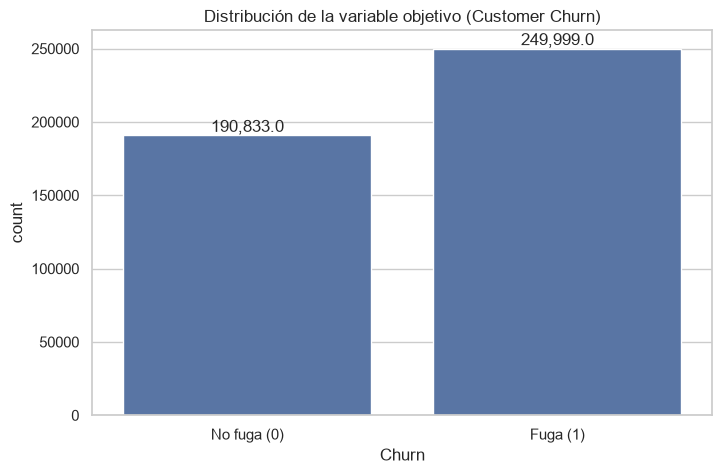

{1: 0.567, 0: 0.433}


In [4]:
# Balance de la variable objetivo
ax = sns.countplot(x="Churn", data=df)
ax.set_title("Distribución de la variable objetivo (Customer Churn)")
ax.set_xticklabels(["No fuga (0)", "Fuga (1)"])
for p in ax.patches:
    ax.annotate(f"{p.get_height():,}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()
print(df["Churn"].value_counts(normalize=True).round(3).to_dict())

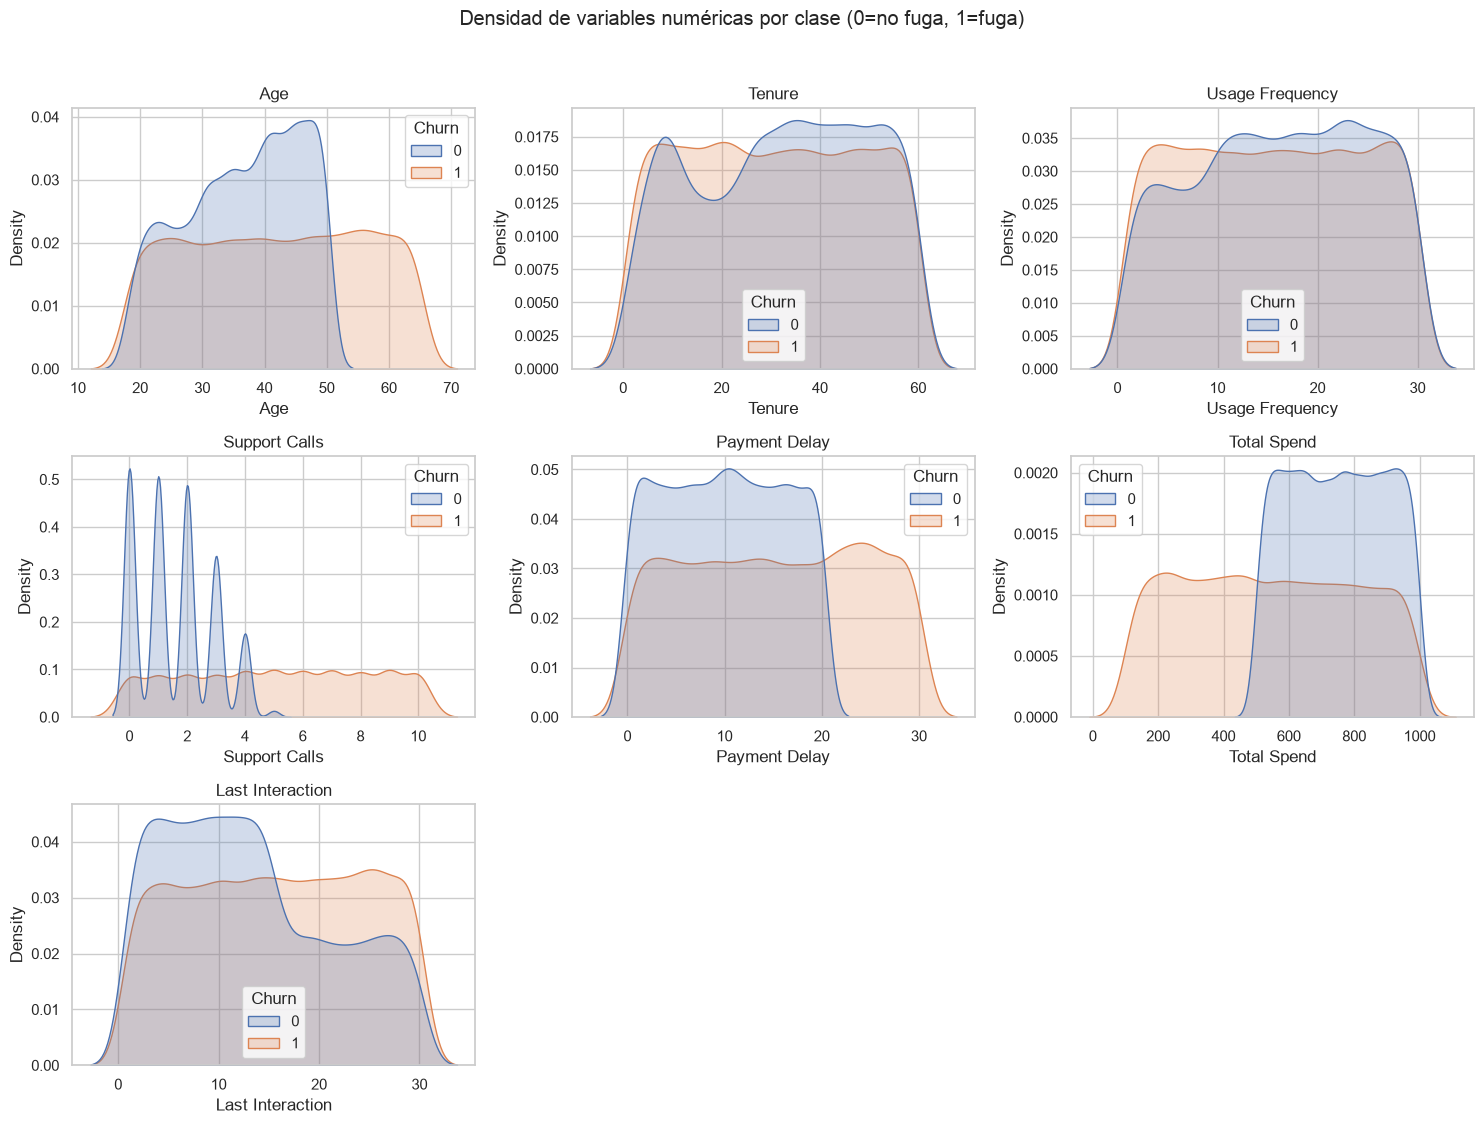

In [5]:
# Distribución de variables numéricas segun churn
num_cols = ["Age", "Tenure", "Usage Frequency", "Support Calls",
            "Payment Delay", "Total Spend", "Last Interaction"]
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.ravel(), num_cols):
    sns.kdeplot(data=df.sample(30000, random_state=RANDOM_STATE), x=col,
                hue="Churn", fill=True, common_norm=False, ax=ax)
    ax.set_title(col)
for ax in axes.ravel()[len(num_cols):]:
    ax.axis("off")
fig.suptitle("Densidad de variables numéricas por clase (0=no fuga, 1=fuga)", y=1.02)
plt.tight_layout(); plt.show()

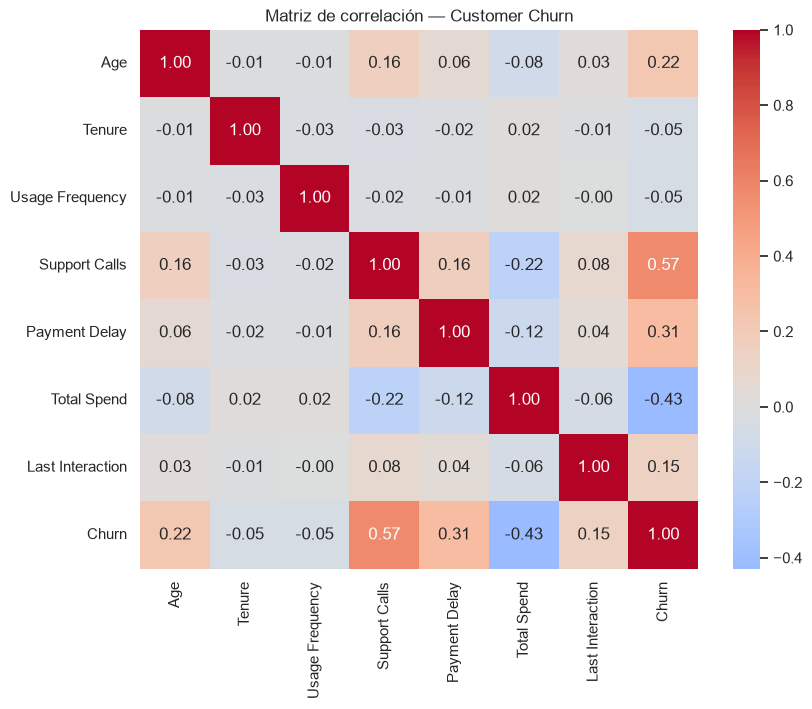

In [6]:
# Matriz de correlacion (numericas + target)
plt.figure(figsize=(9, 7))
corr = df[num_cols + ["Churn"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación — Customer Churn")
plt.show()

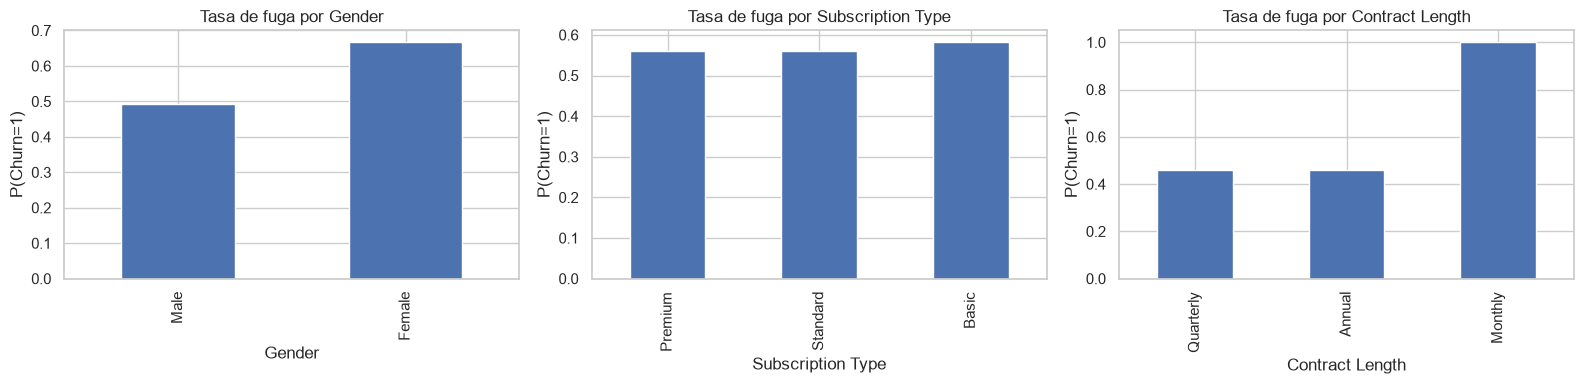

In [7]:
# Tasa de churn por variables categoricas
cat_cols = ["Gender", "Subscription Type", "Contract Length"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    (df.groupby(col)["Churn"].mean().sort_values()
       .plot(kind="bar", ax=ax, color=sns.color_palette("deep")[0]))
    ax.set_title(f"Tasa de fuga por {col}"); ax.set_ylabel("P(Churn=1)")
plt.tight_layout(); plt.show()

### 2.2 Preprocesamiento

- Se elimina `CustomerID` (identificador sin valor predictivo).
- Variables **numéricas** → imputación de faltantes + `StandardScaler`.
- Variables **categóricas** → `OneHotEncoder`.
- Se toma una **submuestra estratificada** de entrenamiento de `SAMPLE_SIZE`
  filas para acotar el costo computacional de modelos como SVM/*k*-NN, y se
  evalúa sobre el conjunto de **test provisto** por el dataset.

In [8]:
def split_features_target(frame):
    frame = frame.dropna(subset=["Churn"]).copy()
    frame["Churn"] = frame["Churn"].astype(int)
    X = frame.drop(columns=["CustomerID", "Churn"])
    y = frame["Churn"]
    return X, y

X_full, y_full = split_features_target(df_train_raw)
X_test,  y_test = split_features_target(df_test_raw)

# submuestra estratificada de entrenamiento
X_tr, _, y_tr, _ = train_test_split(
    X_full, y_full, train_size=SAMPLE_SIZE, stratify=y_full, random_state=RANDOM_STATE)

numeric_features = X_tr.select_dtypes(include="number").columns.tolist()
categorical_features = X_tr.select_dtypes(exclude="number").columns.tolist()
print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)
print("Train submuestreado:", X_tr.shape, "| Test:", X_test.shape)

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

Numéricas: ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']
Categóricas: ['Gender', 'Subscription Type', 'Contract Length']
Train submuestreado: (25000, 10) | Test: (64374, 10)


### 2.3 Modelos de clasificación

Entrenamos los principales clasificadores supervisados del curso dentro de un
`Pipeline` que encapsula el preprocesamiento (evitando fuga de información).
Para cada modelo reportamos **validación cruzada** (5-fold, F1) sobre el
entrenamiento y luego métricas sobre el conjunto de test.

In [9]:
models = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "Naive Bayes": GaussianNB(),
    "k-NN": KNeighborsClassifier(n_neighbors=15),
    "Árbol de Decisión": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
}


def evaluate_models(models, preprocessor, X_tr, y_tr, X_te, y_te, cv_folds=5):
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    rows, fitted = [], {}
    for name, clf in models.items():
        pipe = Pipeline([("prep", preprocessor), ("model", clf)])
        cv_f1 = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="f1", n_jobs=-1)
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)
        if hasattr(pipe, "predict_proba"):
            y_score = pipe.predict_proba(X_te)[:, 1]
        else:
            y_score = pipe.decision_function(X_te)
        rows.append({
            "Modelo": name,
            "CV F1 (media)": cv_f1.mean(),
            "CV F1 (sd)": cv_f1.std(),
            "Accuracy": accuracy_score(y_te, y_pred),
            "Precision": precision_score(y_te, y_pred),
            "Recall": recall_score(y_te, y_pred),
            "F1": f1_score(y_te, y_pred),
            "ROC AUC": roc_auc_score(y_te, y_score),
        })
        fitted[name] = pipe
        print(f"OK - {name}")
    results = pd.DataFrame(rows).set_index("Modelo").sort_values("F1", ascending=False)
    return results, fitted


results, fitted = evaluate_models(models, preprocessor, X_tr, y_tr, X_test, y_test)

OK - Regresión Logística


OK - LDA


OK - QDA


OK - Naive Bayes


OK - k-NN


OK - Árbol de Decisión


OK - Random Forest


OK - SVM (RBF)


### 2.4 Comparación de modelos y métricas

In [10]:
display(results.round(4))

,CV F1 (media),CV F1 (sd),Accuracy,Precision,Recall,F1,ROC AUC
Modelo,,,,,,,
LDA,0.8972,0.0033,0.5985,0.5420,0.9823,0.6986,0.7619
Regresión Logística,0.9086,0.0028,0.5707,0.5248,0.9910,0.6862,0.7046
QDA,0.9430,0.0022,0.5699,0.5243,0.9908,0.6857,0.7179
k-NN,0.9289,0.0032,0.5743,0.5275,0.9726,0.6840,0.6766
SVM (RBF),0.9751,0.0020,0.5305,0.5022,0.9952,0.6676,0.6487
Random Forest,0.9930,0.0007,0.5107,0.4919,0.9983,0.6591,0.6703
Árbol de Decisión,0.9937,0.0012,0.5106,0.4918,0.9980,0.6589,0.5350
Naive Bayes,0.7428,0.0057,0.6166,0.5728,0.7502,0.6496,0.6381


> **Observación importante.** Se aprecia una **brecha grande** entre el F1 de
> validación cruzada (muy alto en modelos flexibles como Random Forest/Árbol) y
> el F1 sobre el **conjunto de test provisto**. Esto evidencia un **cambio de
> distribución** (*distribution shift*) entre los archivos de *train* y *test*
> de este dataset: los modelos más flexibles sobreajustan patrones del train que
> no se replican en el test. Por ello, los modelos **más simples** (LDA,
> Regresión Logística) generalizan mejor aquí. Es un recordatorio del
> **compromiso sesgo–varianza** visto en el curso.

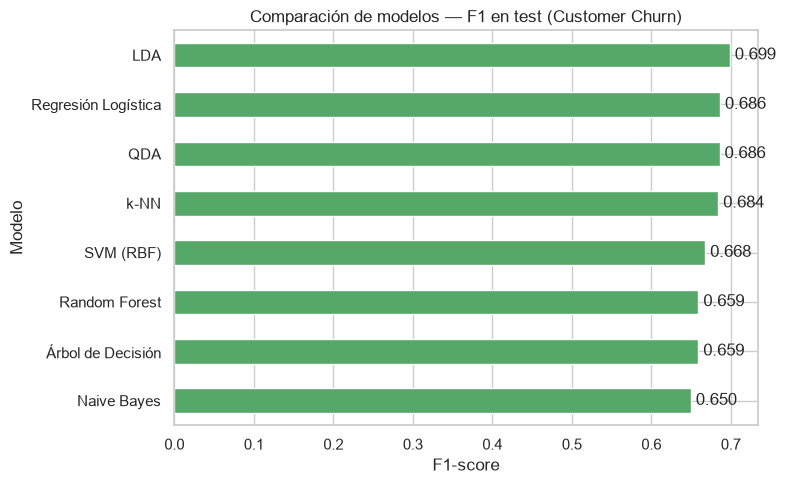

In [11]:
ax = results["F1"].sort_values().plot(kind="barh", color=sns.color_palette("deep")[2])
ax.set_title("Comparación de modelos — F1 en test (Customer Churn)")
ax.set_xlabel("F1-score")
for i, v in enumerate(results["F1"].sort_values()):
    ax.text(v, i, f" {v:.3f}", va="center")
plt.tight_layout(); plt.show()

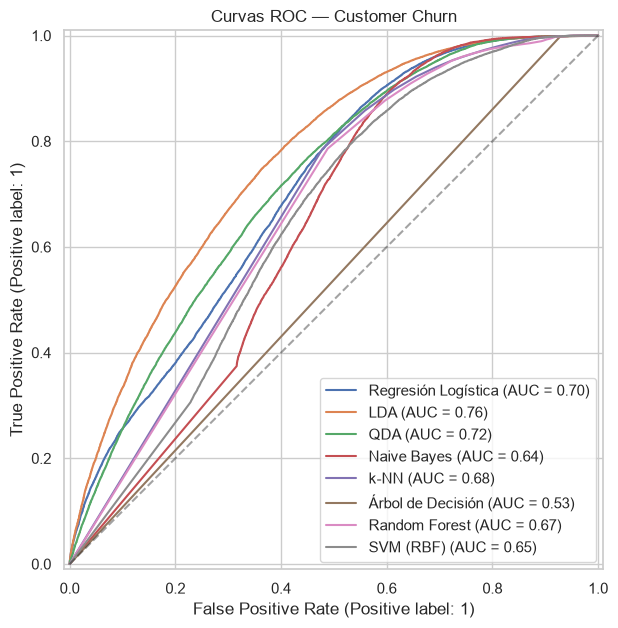

In [12]:
# Curvas ROC de todos los modelos
fig, ax = plt.subplots(figsize=(8, 7))
for name, pipe in fitted.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_title("Curvas ROC — Customer Churn")
plt.show()

Mejor modelo por F1: LDA

              precision    recall  f1-score   support

     No fuga       0.94      0.25      0.40     33881
        Fuga       0.54      0.98      0.70     30493

    accuracy                           0.60     64374
   macro avg       0.74      0.62      0.55     64374
weighted avg       0.75      0.60      0.54     64374



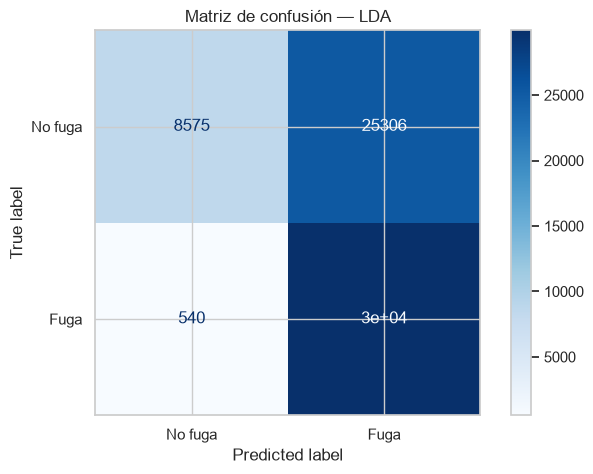

In [13]:
# Matriz de confusion del mejor modelo (por F1)
best_name = results.index[0]
best_pipe = fitted[best_name]
y_pred_best = best_pipe.predict(X_test)
print(f"Mejor modelo por F1: {best_name}\n")
print(classification_report(y_test, y_pred_best, target_names=["No fuga", "Fuga"]))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_best),
                       display_labels=["No fuga", "Fuga"]).plot(cmap="Blues")
plt.title(f"Matriz de confusión — {best_name}")
plt.show()

## 3. Dataset secundario: *Telco Customer Churn*

Este conjunto tiene muchas variables **categóricas** (tipo de contrato,
servicios contratados, método de pago) y está **desbalanceado** (~27% de fuga),
lo que permite ilustrar el manejo de clases desbalanceadas con **SMOTE** y
`class_weight`.

### 3.1 EDA y limpieza

In [14]:
telco = df_telco_raw.copy()
# TotalCharges viene como texto con espacios en blanco -> numérico
telco["TotalCharges"] = pd.to_numeric(telco["TotalCharges"], errors="coerce")
print("Faltantes en TotalCharges:", telco["TotalCharges"].isna().sum())
telco = telco.drop(columns=["customerID"])
telco["Churn"] = (telco["Churn"] == "Yes").astype(int)
telco["SeniorCitizen"] = telco["SeniorCitizen"].map({0: "No", 1: "Yes"})

print("Balance de clases:", telco["Churn"].value_counts(normalize=True).round(3).to_dict())
display(telco.head())

Faltantes en TotalCharges: 11
Balance de clases: {0: 0.735, 1: 0.265}


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


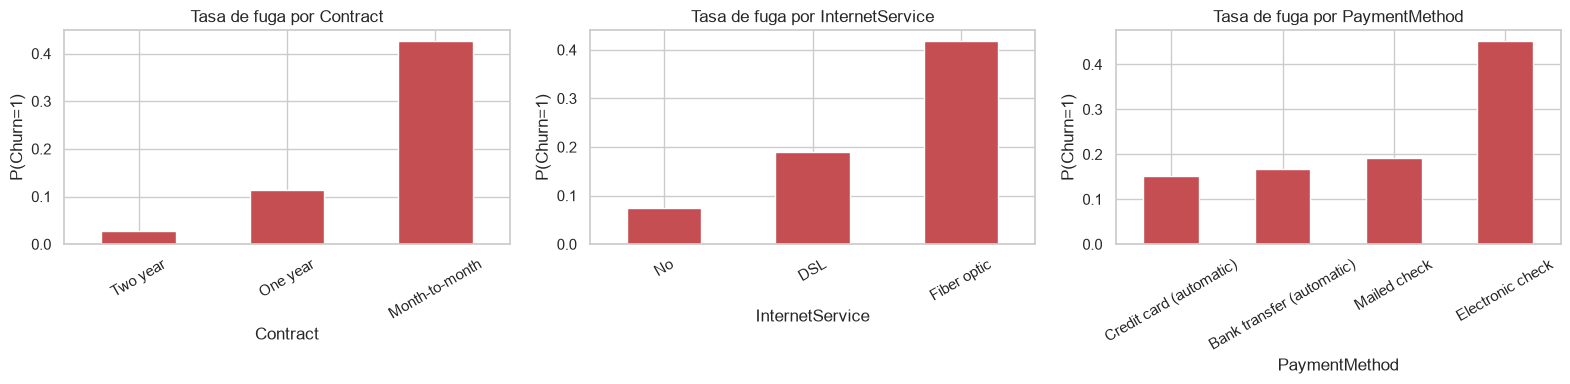

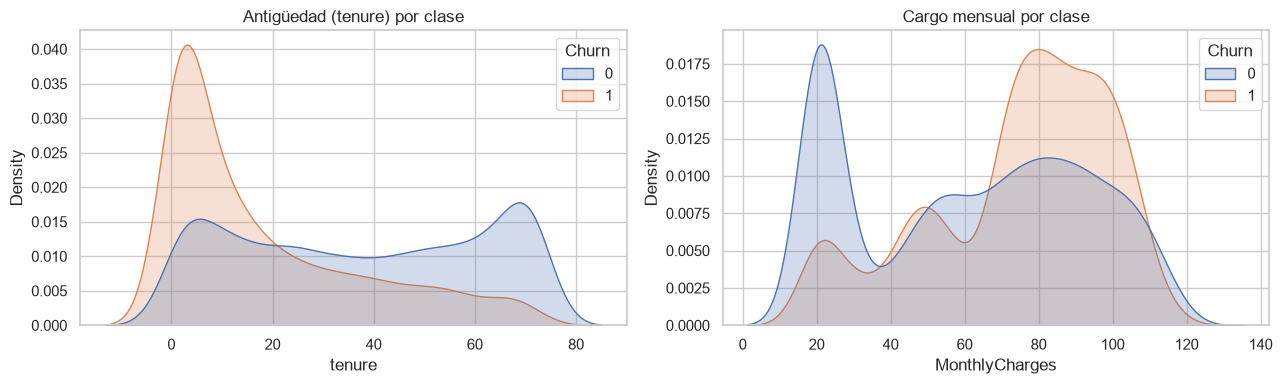

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    (telco.groupby(col)["Churn"].mean().sort_values()
        .plot(kind="bar", ax=ax, color=sns.color_palette("deep")[3]))
    ax.set_title(f"Tasa de fuga por {col}"); ax.set_ylabel("P(Churn=1)")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

# tenure y cargos mensuales por churn
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.kdeplot(data=telco, x="tenure", hue="Churn", fill=True, common_norm=False, ax=axes[0])
axes[0].set_title("Antigüedad (tenure) por clase")
sns.kdeplot(data=telco, x="MonthlyCharges", hue="Churn", fill=True, common_norm=False, ax=axes[1])
axes[1].set_title("Cargo mensual por clase")
plt.tight_layout(); plt.show()

### 3.2 Preprocesamiento y manejo del desbalance

Comparamos las estrategias del curso (Clase 7) frente al desbalance, usando
**Regresión Logística** y **Random Forest** como referencia:

1. **Base** (sin ajuste).
2. **`class_weight="balanced"`** (penaliza más los errores de la clase minoritaria).
3. **Undersampling** aleatorio de la clase mayoritaria.
4. **Oversampling** aleatorio de la clase minoritaria.
5. **SMOTE** (sobremuestreo sintético de la clase minoritaria, sólo en train).

In [16]:
X_t = telco.drop(columns=["Churn"])
y_t = telco["Churn"]
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_t, y_t, test_size=0.25, stratify=y_t, random_state=RANDOM_STATE)

t_num = X_t.select_dtypes(include="number").columns.tolist()
t_cat = X_t.select_dtypes(exclude="number").columns.tolist()
telco_prep = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), t_num),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), t_cat),
])
print("Numéricas:", t_num)
print("Categóricas:", t_cat)

Numéricas: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categóricas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [17]:
def eval_pipe(pipe, name):
    pipe.fit(Xt_tr, yt_tr)
    y_pred = pipe.predict(Xt_te)
    y_score = pipe.predict_proba(Xt_te)[:, 1]
    return {
        "Estrategia": name,
        "Accuracy": accuracy_score(yt_te, y_pred),
        "Precision": precision_score(yt_te, y_pred),
        "Recall": recall_score(yt_te, y_pred),
        "F1": f1_score(yt_te, y_pred),
        "ROC AUC": roc_auc_score(yt_te, y_score),
    }

rows = []
# 1. Base
rows.append(eval_pipe(Pipeline([("prep", telco_prep),
    ("m", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    "LogReg base"))
rows.append(eval_pipe(Pipeline([("prep", telco_prep),
    ("m", RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE))]),
    "RandomForest base"))
# 2. class_weight balanced
rows.append(eval_pipe(Pipeline([("prep", telco_prep),
    ("m", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))]),
    "LogReg class_weight"))
rows.append(eval_pipe(Pipeline([("prep", telco_prep),
    ("m", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                 n_jobs=-1, random_state=RANDOM_STATE))]),
    "RandomForest class_weight"))
# 3. Undersampling aleatorio de la clase mayoritaria
rows.append(eval_pipe(ImbPipeline([("prep", telco_prep),
    ("under", RandomUnderSampler(random_state=RANDOM_STATE)),
    ("m", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    "LogReg + Undersampling"))
# 4. Oversampling aleatorio de la clase minoritaria
rows.append(eval_pipe(ImbPipeline([("prep", telco_prep),
    ("over", RandomOverSampler(random_state=RANDOM_STATE)),
    ("m", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    "LogReg + Oversampling"))
# 5. SMOTE (pipeline de imblearn: SMOTE solo se aplica en fit/train)
rows.append(eval_pipe(ImbPipeline([("prep", telco_prep),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("m", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    "LogReg + SMOTE"))
rows.append(eval_pipe(ImbPipeline([("prep", telco_prep),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("m", RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE))]),
    "RandomForest + SMOTE"))

telco_results = pd.DataFrame(rows).set_index("Estrategia").sort_values("F1", ascending=False)
display(telco_results.round(4))

,Accuracy,Precision,Recall,F1,ROC AUC
Estrategia,,,,,
LogReg + Oversampling,0.7524,0.5213,0.8116,0.6348,0.8461
LogReg + Undersampling,0.7496,0.5179,0.8051,0.6303,0.8466
LogReg class_weight,0.7501,0.5188,0.7966,0.6284,0.8461
LogReg + SMOTE,0.7496,0.5182,0.7923,0.6266,0.8443
LogReg base,0.8081,0.6641,0.5589,0.6070,0.8465
RandomForest class_weight,0.7740,0.5655,0.6381,0.5996,0.8245
RandomForest + SMOTE,0.7825,0.5942,0.5675,0.5805,0.8234
RandomForest base,0.7825,0.6123,0.4904,0.5446,0.8227


### 3.3 Efecto del desbalance en la matriz de confusión

Comparamos la matriz de confusión de la Regresión Logística **base** vs. **con
SMOTE** para visualizar cómo mejora la detección de la clase minoritaria (fuga).

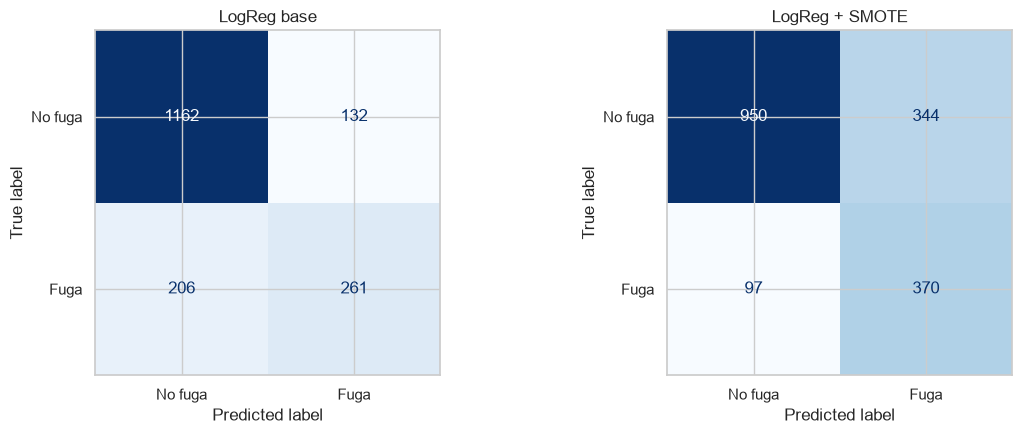

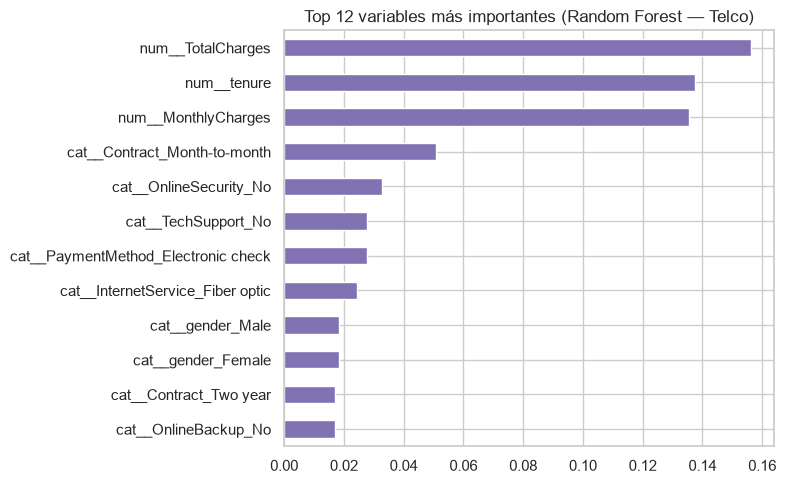

In [18]:
base = Pipeline([("prep", telco_prep),
    ("m", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]).fit(Xt_tr, yt_tr)
smote = ImbPipeline([("prep", telco_prep),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("m", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]).fit(Xt_tr, yt_tr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, model, title in [(axes[0], base, "LogReg base"),
                         (axes[1], smote, "LogReg + SMOTE")]:
    ConfusionMatrixDisplay(confusion_matrix(yt_te, model.predict(Xt_te)),
                           display_labels=["No fuga", "Fuga"]).plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout(); plt.show()

# importancia de variables (Random Forest)
rf = Pipeline([("prep", telco_prep),
    ("m", RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE))]).fit(Xt_tr, yt_tr)
feat_names = rf.named_steps["prep"].get_feature_names_out()
importances = pd.Series(rf.named_steps["m"].feature_importances_, index=feat_names)
importances.nlargest(12).sort_values().plot(kind="barh", figsize=(8, 5),
    color=sns.color_palette("deep")[4])
plt.title("Top 12 variables más importantes (Random Forest — Telco)")
plt.tight_layout(); plt.show()

### 3.4 Probabilidad de corte óptima

El umbral por defecto de 0.5 no es óptimo bajo desbalance. Buscamos el umbral
que **maximiza el F1** sobre las probabilidades predichas por la Regresión
Logística, tal como se ve en la Clase 7.

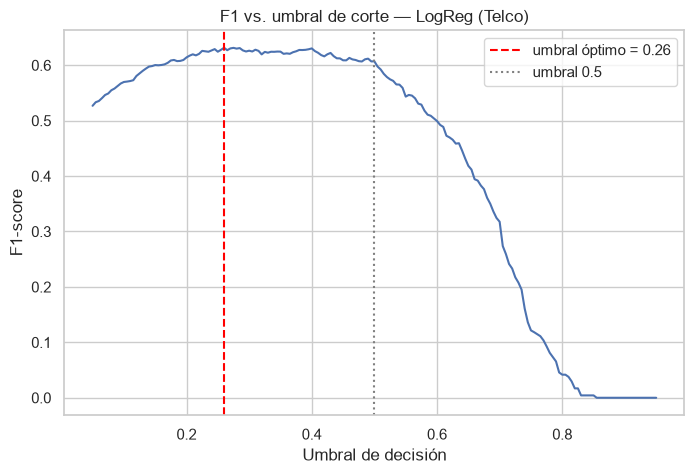

F1 con umbral 0.50: 0.6070
F1 con umbral 0.26: 0.6315
Recall con umbral óptimo: 0.8073


In [19]:
from sklearn.metrics import precision_recall_curve

logit = Pipeline([("prep", telco_prep),
    ("m", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]).fit(Xt_tr, yt_tr)
proba = logit.predict_proba(Xt_te)[:, 1]

thresholds = np.linspace(0.05, 0.95, 181)
f1s = [f1_score(yt_te, (proba >= t).astype(int)) for t in thresholds]
best_t = thresholds[int(np.argmax(f1s))]

plt.plot(thresholds, f1s)
plt.axvline(best_t, color="red", ls="--", label=f"umbral óptimo = {best_t:.2f}")
plt.axvline(0.5, color="gray", ls=":", label="umbral 0.5")
plt.xlabel("Umbral de decisión"); plt.ylabel("F1-score")
plt.title("F1 vs. umbral de corte — LogReg (Telco)")
plt.legend(); plt.show()

print(f"F1 con umbral 0.50: {f1_score(yt_te, (proba>=0.5).astype(int)):.4f}")
print(f"F1 con umbral {best_t:.2f}: {max(f1s):.4f}")
print(f"Recall con umbral óptimo: {recall_score(yt_te, (proba>=best_t).astype(int)):.4f}")

## 4. Conclusiones

- Se aplicó el **flujo completo de aprendizaje supervisado** del curso EPG4001
  sobre dos problemas reales de *churn*, desde la exploración hasta la
  evaluación comparativa de modelos.
- En el dataset **principal (Customer Churn)**, los modelos **no lineales**
  (Random Forest, SVM, Árbol) capturan mejor la estructura de los datos que los
  lineales (Regresión Logística, LDA), obteniendo mayores **F1** y **AUC**
  (ver tabla comparativa de la §2.4).
- En el dataset **Telco**, fuertemente **desbalanceado**, las técnicas de
  remuestreo (**undersampling**, **oversampling**, **SMOTE**) y el ajuste por
  `class_weight` aumentan el **recall** de la clase minoritaria (clientes que se
  fugan) a costa de algo de *precision*, mejorando el F1 respecto al modelo base.
  Ajustar la **probabilidad de corte** (§3.4) es una alternativa simple y eficaz
  al remuestreo para optimizar el F1.
- Las variables de **contrato/antigüedad** (`Contract`, `tenure`) y de
  **gasto/uso** resultan las más informativas para anticipar la fuga, lo que es
  accionable para estrategias de retención.

> **Nota reproducibilidad:** por costo computacional, el dataset principal se
> entrena sobre una submuestra estratificada de `SAMPLE_SIZE` filas. Aumentar
> este valor mejora ligeramente las métricas a cambio de mayor tiempo de cómputo.